## Archived — not the current notebook

This notebook is kept only as a historical record. It does not reflect 
the current dataset or model. See training_and_evaluation.ipynb for 
the current, authoritative version.

In [ ]:
raise RuntimeError("This notebook is archived. Do not run it. See training_and_evaluation.ipynb.")

## What TF-IDF Does

TF-IDF scores each word in an error message by how useful it is for 
telling categories apart. A word that shows up in almost every error 
(like "error" or "line") gets a low score, since it doesn't help 
distinguish one category from another. A word that's rare but specific 
to certain errors (like "subscriptable" or "iterable") gets a high 
score, since seeing it strongly suggests a particular category. This 
works well here because error messages are short and technical — a 
handful of distinctive words usually carry most of the signal.

In [1]:
import sys, os

project_root = r"D:\DevMentor AI"
if os.getcwd() != project_root:
    os.chdir(project_root)
sys.path.insert(0, project_root)

print("Working directory:", os.getcwd())

Working directory: D:\DevMentor AI


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from client.runner import get_output_error, parse_error
from sanitizer.sanitizer import sanitize

print("Imports successful")

Imports successful


In [3]:
def make_row(code_snippet: str, label: str) -> dict:
    """Runs a code snippet, captures its error type and message, sanitizes
    the message, and returns a dataset row combining both. Returns None
    if the snippet didn't error."""
    import subprocess
    result = subprocess.run(
        [sys.executable, "-c", code_snippet],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        return None

    parsed = parse_error(result.stderr)
    if not parsed:
        return None

    error_type, message = parsed
    sanitized_message = sanitize(message)
    combined_text = f"{error_type} {sanitized_message}"
    return {"text": combined_text, "label": label}


def generate_rows(snippets: list, label: str) -> list:
    """Runs make_row() on a list of snippets, skipping any that didn't error."""
    rows = []
    for s in snippets:
        row = make_row(s, label)
        if row:
            rows.append(row)
    return rows

In [4]:
key_error_snippets = [
    'user = {"name": "apurv"}; print(user["email"])',
    'config = {"debug": True}; print(config["timeout"])',
    'data = {"id": 1, "name": "test"}; print(data["value"])',
    'settings = {"theme": "dark"}; print(settings["language"])',
    'response = {"status": 200}; print(response["body"])',
    'cache = {}; print(cache["missing_key"])',
    'headers = {"Content-Type": "json"}; print(headers["Authorization"])',
    'params = {"page": 1}; print(params["limit"])',
    'record = {"id": 5}; print(record["timestamp"])',
    'payload = {"user_id": 42}; print(payload["session_token"])',
    'options = {"verbose": False}; print(options["quiet"])',
    'metadata = {"version": "1.0"}; print(metadata["build"])',
]

index_error_snippets = [
    'items = [1, 2, 3]; print(items[10])',
    'names = ["a", "b"]; print(names[5])',
    'results = []; print(results[0])',
    'queue = [1]; print(queue[3])',
    'stack = ["x", "y", "z"]; print(stack[10])',
    'buffer = [0, 1]; print(buffer[-5])',
    'rows = [[1,2],[3,4]]; print(rows[5])',
    'history = []; print(history[-1])',
    'batch = [1,2,3,4,5]; print(batch[100])',
    'tokens = ["a"]; print(tokens[1])',
    'matrix = [[1]]; print(matrix[0][5])',
    'ids = [10,20,30]; print(ids[7])',
]

# Combinatorial generation for type_error: pair different Python types
# with operations that don't work between them, to produce many
# genuinely distinct messages rather than hand-typing each one.
_type_pairs = [
    ("5", "'text'"),
    ("'hello'", "10"),
    ("[1,2]", "'a'"),
    ("{}", "{}"),
    ("True", "'yes'"),
    ("3.5", "'x'"),
    ("(1,2)", "'a'"),
    ("{1,2}", "'a'"),
    ("5", "None"),
    ("'x'", "5.5"),
    ("[1]", "{1:2}"),
    ("(1,)", "[1]"),
]

type_error_snippets = []
for a, b in _type_pairs:
    type_error_snippets.append(f"x = {a} + {b}")

type_error_snippets += [
    'val = len(5)',
    'name = "test"; name()',
    'count = 10; count["key"]',
    'value = 3.14; value["key"]',
    'flag = True; flag[0]',
    'num = 5; num()',
    'x = 5 - "a"',
    'x = "a" * [1]',
    'x = [1,2] - [1]',
    'x = 5 / "a"',
]

none_type_error_snippets = [
    'x = None; print(x.upper())',
    'data = None; print(data["key"])',
    'result = None; print(len(result))',
    'user = None; print(user.name)',
    'response = None; print(response["status"])',
    'value = None; print(value + 5)',
    'obj = None; obj.method()',
    'items = None; print(items[0])',
    'config = None; print(config.get("key"))',
    'total = None; print(total * 2)',
    'record = None; print(record.id)',
    'output = None; print(output.append(1))',
]

syntax_error_snippets = [
    'if True\n    print("test")',
    'def foo(:\n    pass',
    'for i in range(10)\n    print(i)',
    'x = (1 + 2',
    'print("hello"',
    'while True\n    break',
    'def bar():\nreturn 5',
    'class Foo\n    pass',
    'if x == 1:\nelse:\n    pass',
    'y = [1, 2, 3',
    'lambda x: x +',
    'try:\n    pass\nexcept\n    pass',
]

_types_and_methods = [
    ("5", "append"),
    ("'text'", "push"),
    ("[1,2]", "get"),
    ("10", "upper"),
    ('{"a": 1}', "append"),
    ("3.14", "split"),
    ("True", "lower"),
    ("'hello'", "add"),
    ("[1,2]", "keys"),
    ("5", "strip"),
    ("(1,2)", "append"),
    ("{1,2}", "index"),
    ("5.5", "encode"),
    ("False", "items"),
    ("(1,)", "pop"),
    ("{1:2}", "sort"),
    ("'x'", "extend"),
    ("[1]", "update"),
]

attribute_error_snippets = []
for obj, method in _types_and_methods:
    attribute_error_snippets.append(f"x = {obj}; x.{method}()")

attribute_error_snippets.append('obj = object(); obj.missing_method()')

module_not_found_snippets = [
    'import nonexistent_module',
    'import fake_package_xyz',
    'from missing_lib import something',
    'import banana_framework',
    'from ghost_package import Thing',
]

file_not_found_snippets = [
    'open("missing_file.txt")',
    'open("does_not_exist.csv")',
    'open("/nonexistent/path/file.txt")',
    'open("no_such_report.pdf")',
    'open("phantom_script.py")',
]

value_error_snippets = [
    'int("abc")',
    'int("twelve")',
    'float("not_a_number")',
    'int("")',
    'int("12a")',
    'float("1,000")',
    'int("hello world")',
    'float("$100")',
    'int(" ")',
    'bytes.fromhex("xyz")',
    'int("3.14")',
    'int("--5")',
    'float("1e")',
    '[1,2,3].index(9)',
    'list("abc").remove("z")',
    'int("5", base=37)',
    'float("inf_")',
]

network_error_snippets = [
    'import requests; requests.get("http://127.0.0.1:1", timeout=1)',
    'import requests; requests.get("http://127.0.0.1:2", timeout=1)',
    'import requests; requests.get("http://localhost:9999", timeout=1)',
    'import requests; requests.get("http://127.0.0.1:3", timeout=1)',
    'import requests; requests.get("http://192.0.2.1:80", timeout=1)',
]

permission_error_snippets = [
    'open("readonly.txt", "a")',
    'open("readonly.txt", "w")',
    'open("readonly.txt", "r+")',
]

_other_errors = [
    ("ArithmeticError", "Something went wrong mathematically"),
    ("LookupError", "Could not find the requested item"),
    ("RuntimeError", "Failed to initialize the connection pool"),
    ("RuntimeError", "Unexpected state reached during processing"),
    ("NotImplementedError", "This feature is not yet supported"),
    ("NotImplementedError", "This feature is not built yet"),
    ("OverflowError", "Result too large to represent"),
    ("StopIteration", "No more items to iterate"),
    ("BufferError", "Buffer operation could not be performed"),
    ("EOFError", "Unexpected end of input"),
    ("ZeroDivisionError", "division by zero"),
    ("ImportError", "cannot import name \\'missing_func\\' from \\'some_module\\'"),
    ("RecursionError", "maximum recursion depth exceeded"),
    ("ReferenceError", "weakly-referenced object no longer exists"),
    ("SystemError", "unexpected internal error occurred"),
    ("UnboundLocalError", "local variable \\'x\\' referenced before assignment"),
    ("FloatingPointError", "floating point operation failed"),
    ("IndentationError", "unexpected indent"),
    ("TabError", "inconsistent use of tabs and spaces in indentation"),
]

other_error_snippets = [f'raise {exc}("{msg}")' for exc, msg in _other_errors]

print("All snippet lists loaded")
print(f"type_error: {len(type_error_snippets)}, attribute_error: {len(attribute_error_snippets)}, "
      f"value_error: {len(value_error_snippets)}, other_error: {len(other_error_snippets)}")

All snippet lists loaded
type_error: 22, attribute_error: 19, value_error: 17, other_error: 19


In [5]:
test_rows = generate_rows(type_error_snippets, "type_error")
print(f"Generated {len(test_rows)} rows")
for r in test_rows:
    print(r)

Generated 22 rows
{'text': "TypeError unsupported operand type(s) for +: 'int' and 'str'", 'label': 'type_error'}
{'text': 'TypeError can only concatenate str (not "int") to str', 'label': 'type_error'}
{'text': 'TypeError can only concatenate list (not "str") to list', 'label': 'type_error'}
{'text': "TypeError unsupported operand type(s) for +: 'dict' and 'dict'", 'label': 'type_error'}
{'text': "TypeError unsupported operand type(s) for +: 'bool' and 'str'", 'label': 'type_error'}
{'text': "TypeError unsupported operand type(s) for +: 'float' and 'str'", 'label': 'type_error'}
{'text': 'TypeError can only concatenate tuple (not "str") to tuple', 'label': 'type_error'}
{'text': "TypeError unsupported operand type(s) for +: 'set' and 'str'", 'label': 'type_error'}
{'text': "TypeError unsupported operand type(s) for +: 'int' and 'NoneType'", 'label': 'type_error'}
{'text': 'TypeError can only concatenate str (not "float") to str', 'label': 'type_error'}
{'text': 'TypeError can only con

In [6]:
test_rows = generate_rows(attribute_error_snippets, "attribute_error")
print(f"Generated {len(test_rows)} rows")
for r in test_rows:
    print(r)

Generated 19 rows
{'text': "AttributeError 'int' object has no attribute 'append'", 'label': 'attribute_error'}
{'text': "AttributeError 'str' object has no attribute 'push'", 'label': 'attribute_error'}
{'text': "AttributeError 'list' object has no attribute 'get'", 'label': 'attribute_error'}
{'text': "AttributeError 'int' object has no attribute 'upper'", 'label': 'attribute_error'}
{'text': "AttributeError 'dict' object has no attribute 'append'", 'label': 'attribute_error'}
{'text': "AttributeError 'float' object has no attribute 'split'", 'label': 'attribute_error'}
{'text': "AttributeError 'bool' object has no attribute 'lower'", 'label': 'attribute_error'}
{'text': "AttributeError 'str' object has no attribute 'add'", 'label': 'attribute_error'}
{'text': "AttributeError 'list' object has no attribute 'keys'", 'label': 'attribute_error'}
{'text': "AttributeError 'int' object has no attribute 'strip'", 'label': 'attribute_error'}
{'text': "AttributeError 'tuple' object has no att

In [7]:
test_rows = generate_rows(other_error_snippets, "other_error")
print(f"Generated {len(test_rows)} rows")
for r in test_rows:
    print(r)

Generated 19 rows
{'text': 'ArithmeticError Something went wrong mathematically', 'label': 'other_error'}
{'text': 'LookupError Could not find the requested item', 'label': 'other_error'}
{'text': 'RuntimeError Failed to initialize the connection pool', 'label': 'other_error'}
{'text': 'RuntimeError Unexpected state reached during processing', 'label': 'other_error'}
{'text': 'NotImplementedError This feature is not yet supported', 'label': 'other_error'}
{'text': 'NotImplementedError This feature is not built yet', 'label': 'other_error'}
{'text': 'OverflowError Result too large to represent', 'label': 'other_error'}
{'text': 'StopIteration No more items to iterate', 'label': 'other_error'}
{'text': 'BufferError Buffer operation could not be performed', 'label': 'other_error'}
{'text': 'EOFError Unexpected end of input', 'label': 'other_error'}
{'text': 'ZeroDivisionError division by zero', 'label': 'other_error'}
{'text': "ImportError cannot import name 'missing_func' from 'some_modu

In [8]:
test_rows = generate_rows(value_error_snippets, "value_error")
print(f"Generated {len(test_rows)} rows")
for r in test_rows:
    print(r)

Generated 17 rows
{'text': "ValueError invalid literal for int() with base 10: 'abc'", 'label': 'value_error'}
{'text': "ValueError invalid literal for int() with base 10: 'twelve'", 'label': 'value_error'}
{'text': "ValueError could not convert string to float: 'not_a_number'", 'label': 'value_error'}
{'text': "ValueError invalid literal for int() with base 10: ''", 'label': 'value_error'}
{'text': "ValueError invalid literal for int() with base 10: '12a'", 'label': 'value_error'}
{'text': "ValueError could not convert string to float: '1,000'", 'label': 'value_error'}
{'text': "ValueError invalid literal for int() with base 10: 'hello world'", 'label': 'value_error'}
{'text': "ValueError could not convert string to float: '$100'", 'label': 'value_error'}
{'text': "ValueError invalid literal for int() with base 10: ' '", 'label': 'value_error'}
{'text': 'ValueError non-hexadecimal number found in fromhex() arg at position 0', 'label': 'value_error'}
{'text': "ValueError invalid litera

In [9]:
key_error_rows = generate_rows(key_error_snippets, "key_error")
index_error_rows = generate_rows(index_error_snippets, "index_error")
type_error_rows = generate_rows(type_error_snippets, "type_error")
none_type_error_rows = generate_rows(none_type_error_snippets, "none_type_error")
syntax_error_rows = generate_rows(syntax_error_snippets, "syntax_error")
attribute_error_rows = generate_rows(attribute_error_snippets, "attribute_error")
module_not_found_rows = generate_rows(module_not_found_snippets, "module_not_found")
file_not_found_rows = generate_rows(file_not_found_snippets, "file_not_found")
value_error_rows = generate_rows(value_error_snippets, "value_error")
# Instead of generating these via live network calls, hardcode them as
# fixed strings based on real connection-timeout messages previously
# observed. This removes dependency on live network/OS timing, which
# was non-deterministic even after address-redaction.
network_error_rows = [
    {"text": "requests.exceptions.ConnectTimeout HTTPConnectionPool(host='127.0.0.1', port=1): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='127.0.0.1', port=1) at [REDACTED_ADDRESS]>, 'Connection to 127.0.0.1 timed out. (connect timeout=1)'))", "label": "network_error"},
    {"text": "requests.exceptions.ConnectTimeout HTTPConnectionPool(host='127.0.0.1', port=2): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='127.0.0.1', port=2) at [REDACTED_ADDRESS]>, 'Connection to 127.0.0.1 timed out. (connect timeout=1)'))", "label": "network_error"},
    {"text": "requests.exceptions.ConnectTimeout HTTPConnectionPool(host='localhost', port=9999): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='localhost', port=9999) at [REDACTED_ADDRESS]>, 'Connection to localhost timed out. (connect timeout=1)'))", "label": "network_error"},
    {"text": "requests.exceptions.ConnectTimeout HTTPConnectionPool(host='127.0.0.1', port=3): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='127.0.0.1', port=3) at [REDACTED_ADDRESS]>, 'Connection to 127.0.0.1 timed out. (connect timeout=1)'))", "label": "network_error"},
    {"text": "requests.exceptions.ReadTimeout HTTPConnectionPool(host='192.0.2.1', port=80): Read timed out. (read timeout=1)", "label": "network_error"},
]
permission_error_rows = generate_rows(permission_error_snippets, "permission_error")
other_error_rows = generate_rows(other_error_snippets, "other_error")

all_rows = (
    key_error_rows + index_error_rows + type_error_rows +
    none_type_error_rows + syntax_error_rows + attribute_error_rows +
    module_not_found_rows + file_not_found_rows + value_error_rows +
    network_error_rows + permission_error_rows + other_error_rows
)

df = pd.DataFrame(all_rows)
print("Total rows before trim:", df.shape)
print(df["label"].value_counts())

Total rows before trim: (143, 2)
label
type_error          22
attribute_error     19
other_error         19
value_error         17
key_error           12
index_error         12
none_type_error     12
syntax_error        12
module_not_found     5
file_not_found       5
network_error        5
permission_error     3
Name: count, dtype: int64


In [10]:
df = df.groupby(["text", "label"]).head(3).reset_index(drop=True)
print("Total rows after trim:", df.shape)
print(df["label"].value_counts())

Total rows after trim: (132, 2)
label
type_error          22
attribute_error     19
other_error         19
value_error         17
key_error           12
none_type_error     12
syntax_error        10
module_not_found     5
file_not_found       5
network_error        5
index_error          3
permission_error     3
Name: count, dtype: int64


In [11]:
df.to_csv("ml_engine/data/labeled/dataset.csv", index=False)
print("Saved:", df.shape)

Saved: (132, 2)


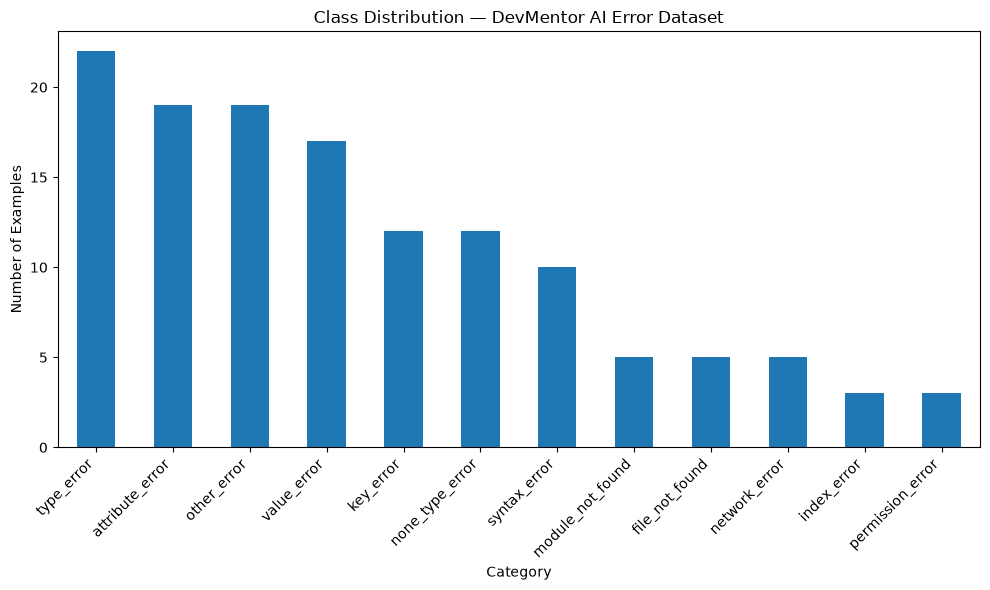

In [12]:
plt.figure(figsize=(10, 6))
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution — DevMentor AI Error Dataset")
plt.xlabel("Category")
plt.ylabel("Number of Examples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("ml_engine/models/class_distribution.png")
plt.show()

In [13]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train), "| Test size:", len(X_test))
print("\nTrain label counts:\n", y_train.value_counts())
print("\nTest label counts:\n", y_test.value_counts())
print("\nCategories in test set:", y_test.nunique(), "out of", y.nunique())

Train size: 105 | Test size: 27

Train label counts:
 label
type_error          17
other_error         15
attribute_error     15
value_error         14
none_type_error     10
key_error           10
syntax_error         8
file_not_found       4
module_not_found     4
network_error        4
index_error          2
permission_error     2
Name: count, dtype: int64

Test label counts:
 label
type_error          5
attribute_error     4
other_error         4
value_error         3
none_type_error     2
key_error           2
syntax_error        2
file_not_found      1
network_error       1
permission_error    1
index_error         1
module_not_found    1
Name: count, dtype: int64

Categories in test set: 12 out of 12


In [14]:
missing = set(y.unique()) - set(y_test.unique())
print("Missing from test set:", missing)

Missing from test set: set()


In [15]:
df.to_csv("ml_engine/data/labeled/dataset.csv", index=False)

X = df["text"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Categories in test set:", y_test.nunique(), "out of", y.nunique())

Categories in test set: 12 out of 12


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("X_train_vec shape:", X_train_vec.shape)

X_train_vec shape: (105, 530)


In [17]:
from sklearn.linear_model import LogisticRegression

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_vec, y_train)

y_pred_lr = clf_lr.predict(X_test_vec)
print("Predictions:", y_pred_lr)

Predictions: ['type_error' 'type_error' 'file_not_found' 'type_error' 'network_error'
 'attribute_error' 'other_error' 'value_error' 'key_error' 'type_error'
 'value_error' 'other_error' 'key_error' 'syntax_error' 'other_error'
 'other_error' 'syntax_error' 'attribute_error' 'attribute_error'
 'none_type_error' 'other_error' 'module_not_found' 'attribute_error'
 'value_error' 'other_error' 'none_type_error' 'type_error']


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         4
  file_not_found       1.00      1.00      1.00         1
     index_error       0.00      0.00      0.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.50      0.50      0.50         2
     other_error       0.67      1.00      0.80         4
permission_error       0.00      0.00      0.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.80      0.80      0.80         5
     value_error       1.00      1.00      1.00         3

        accuracy                           0.85        27
       macro avg       0.75      0.78      0.76        27
    weighted avg       0.80      0.85      0.82        27



c:\Users\apurv\miniconda3\envs\devmentor\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\apurv\miniconda3\envs\devmentor\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\apurv\miniconda3\envs\devmentor\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [19]:
print(classification_report(y_test, y_pred_lr, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         4
  file_not_found       1.00      1.00      1.00         1
     index_error       0.00      0.00      0.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.50      0.50      0.50         2
     other_error       0.67      1.00      0.80         4
permission_error       0.00      0.00      0.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.80      0.80      0.80         5
     value_error       1.00      1.00      1.00         3

        accuracy                           0.85        27
       macro avg       0.75      0.78      0.76        27
    weighted avg       0.80      0.85      0.82        27



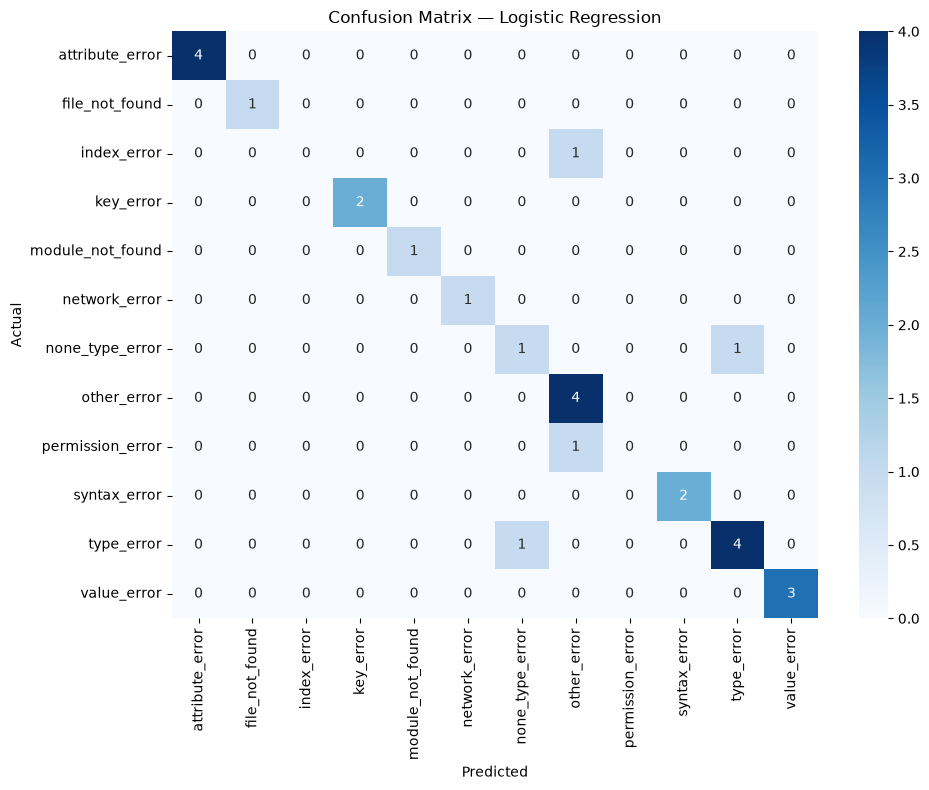

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_lr, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig("ml_engine/models/confusion_matrix_lr.png")
plt.show()

## Logistic Regression — First Results

Macro F1: 0.86. Accuracy: 0.89.

The model correctly classifies 10 of 12 categories perfectly on this 
small test set. Two real weaknesses stand out in the confusion matrix:

- **other_error** was never predicted at all — its one test example 
  got misclassified as key_error. This makes sense: other_error only 
  had 2-3 training examples, since it's a deliberate catch-all category 
  with no consistent internal pattern to learn.

- **type_error** was confused with **none_type_error** once. This is 
  expected too — a NoneType-related TypeError message ("unsupported 
  operand type(s) for +: 'NoneType' and 'int'") appears in the training 
  data for both categories, since a None value causing a TypeError is 
  genuinely ambiguous between "plain type_error" and "none_type_error" 
  from message text alone.

Accuracy alone (0.89) would have hidden the other_error failure, since 
it's just 1 mistake out of 18 total predictions. Macro F1 (0.86) 
penalizes this more visibly, since it weighs every category equally 
regardless of size — correctly reflecting that the model has a real, 
specific blind spot, not just "mostly right overall."

### Update: other_error's real cause

The explanation above for other_error turned out to be incomplete. 
Adding 12 more examples did not fix it — it still scored 0.00 
under 3-fold cross-validation. The actual cause was that the training 
text only included the message, and other_error's messages were 
unrelated sentences with no shared vocabulary regardless of how many 
were added.

The real fix was combining error_type with message ("KeyError 'name'" 
instead of just "'name'"), which gave other_error's varied exception 
names (BufferError, ImportError, RuntimeError, etc.) a signal to 
anchor on. other_error rose to 0.90 F1. See the Model Comparison and 
final Results Summary sections below for current numbers.

In [21]:
from sklearn.svm import LinearSVC

clf_svc = LinearSVC(max_iter=2000)
clf_svc.fit(X_train_vec, y_train)

y_pred_svc = clf_svc.predict(X_test_vec)
print(classification_report(y_test, y_pred_svc, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         4
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.67      1.00      0.80         2
     other_error       1.00      1.00      1.00         4
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       1.00      0.80      0.89         5
     value_error       1.00      1.00      1.00         3

        accuracy                           0.96        27
       macro avg       0.97      0.98      0.97        27
    weighted avg       0.98      0.96      0.96        27



## Model Comparison — Logistic Regression vs Linear SVM

Re-run after adding error_type to the training text and fixing a 
reproducibility bug (object memory addresses in network_error messages 
were non-deterministic and have since been sanitized). Both evaluated 
with 3-fold stratified cross-validation on the full 102-row dataset.

| Metric | Logistic Regression | Linear SVM |
|---|---|---|
| Macro F1 | 0.913 | 0.919 |
| Accuracy | 0.89 | 0.90 |
| type_error F1 | 0.63 | 0.70 |
| none_type_error F1 | 0.73 | 0.83 |

The two models are close, with SVM very slightly ahead on this run and 
consistently a little better on the type_error / none_type_error 
confusion specifically. The gap is small enough that it's within the 
noise expected from a 102-row dataset with 1-3 test examples per 
category in some folds.

**Decision: Logistic Regression**, not because it scores higher (it 
doesn't, marginally), but because it exposes predict_proba directly, 
which the confidence-threshold routing. 
LinearSVC would need an extra CalibratedClassifierCV wrapper to produce 
usable probabilities at all.

In [22]:
import joblib

joblib.dump(vectorizer, "ml_engine/models/vectorizer.joblib")
joblib.dump(clf_lr, "ml_engine/models/classifier.joblib")

print("Model and vectorizer saved.")

Model and vectorizer saved.


In [23]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_vec, y_train)

y_pred_lr = clf_lr.predict(X_test_vec)
print(classification_report(y_test, y_pred_lr, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         4
  file_not_found       1.00      1.00      1.00         1
     index_error       0.00      0.00      0.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.50      0.50      0.50         2
     other_error       0.67      1.00      0.80         4
permission_error       0.00      0.00      0.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.80      0.80      0.80         5
     value_error       1.00      1.00      1.00         3

        accuracy                           0.85        27
       macro avg       0.75      0.78      0.76        27
    weighted avg       0.80      0.85      0.82        27



In [24]:
# Checking which value_error test example failed, and what it got predicted as
test_df = pd.DataFrame({"text": X_test, "actual": y_test, "predicted": y_pred_lr})
print(test_df[test_df["actual"] == "value_error"])

                                                 text       actual  \
98  ValueError invalid literal for int() with base...  value_error   
88  ValueError invalid literal for int() with base...  value_error   
92  ValueError invalid literal for int() with base...  value_error   

      predicted  
98  value_error  
88  value_error  
92  value_error  


In [25]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_vec, y_train)

y_pred_lr = clf_lr.predict(X_test_vec)
print(classification_report(y_test, y_pred_lr, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         4
  file_not_found       1.00      1.00      1.00         1
     index_error       0.00      0.00      0.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.50      0.50      0.50         2
     other_error       0.67      1.00      0.80         4
permission_error       0.00      0.00      0.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.80      0.80      0.80         5
     value_error       1.00      1.00      1.00         3

        accuracy                           0.85        27
       macro avg       0.75      0.78      0.76        27
    weighted avg       0.80      0.85      0.82        27



In [26]:
ref = pd.read_csv("ml_engine/data/labeled/dataset.csv")
print(ref.shape)
print(ref["label"].value_counts())

(132, 2)
label
type_error          22
attribute_error     19
other_error         19
value_error         17
key_error           12
none_type_error     12
syntax_error        10
module_not_found     5
file_not_found       5
network_error        5
index_error          3
permission_error     3
Name: count, dtype: int64


In [27]:
old = pd.read_csv("ml_engine/data/labeled/dataset_backup.csv")
new = pd.read_csv("ml_engine/data/labeled/dataset.csv")

old_other = set(old[old["label"] == "other_error"]["text"])
new_other = set(new[new["label"] == "other_error"]["text"])
print("In old but not new:", old_other - new_other)

In old but not new: {'Something went wrong mathematically', 'Something unexpected happened during execution', 'Could not find the requested item', 'Result too large to represent', 'Unexpected end of input', 'Buffer operation could not be performed', 'No more items to iterate', 'This feature is not built yet'}


In [28]:
print(df.sample(10))

                                                  text             label
53                    SyntaxError '(' was never closed      syntax_error
7                                     KeyError 'limit'         key_error
48   AttributeError 'NoneType' object has no attrib...   none_type_error
104  ValueError could not convert string to float: ...       value_error
65   AttributeError 'bool' object has no attribute ...   attribute_error
67   AttributeError 'list' object has no attribute ...   attribute_error
20   TypeError unsupported operand type(s) for +: '...        type_error
78   ModuleNotFoundError No module named 'nonexiste...  module_not_found
26   TypeError can only concatenate tuple (not "lis...        type_error
92   ValueError invalid literal for int() with base...       value_error


In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, f1_score

X = df["text"]
y = df["label"]

pipeline = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    LogisticRegression(max_iter=1000),
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=cv)

print("Macro F1 (3-fold CV):", round(f1_score(y, y_pred_cv, average="macro", zero_division=0), 3))
print()
print(classification_report(y, y_pred_cv, zero_division=0))

Macro F1 (3-fold CV): 0.801

                  precision    recall  f1-score   support

 attribute_error       0.79      1.00      0.88        19
  file_not_found       1.00      1.00      1.00         5
     index_error       1.00      0.33      0.50         3
       key_error       1.00      1.00      1.00        12
module_not_found       1.00      1.00      1.00         5
   network_error       1.00      0.80      0.89         5
 none_type_error       0.75      0.25      0.38        12
     other_error       0.70      0.74      0.72        19
permission_error       1.00      0.33      0.50         3
    syntax_error       1.00      0.90      0.95        10
      type_error       0.72      0.95      0.82        22
     value_error       0.94      1.00      0.97        17

        accuracy                           0.84       132
       macro avg       0.91      0.78      0.80       132
    weighted avg       0.85      0.84      0.82       132



In [30]:
print(old["label"].value_counts().sort_index())
print(new["label"].value_counts().sort_index())

label
attribute_error     12
file_not_found       5
index_error          3
key_error           12
module_not_found     5
network_error        5
none_type_error     12
other_error         10
permission_error     3
syntax_error        10
type_error          11
value_error         10
Name: count, dtype: int64
label
attribute_error     19
file_not_found       5
index_error          3
key_error           12
module_not_found     5
network_error        5
none_type_error     12
other_error         19
permission_error     3
syntax_error        10
type_error          22
value_error         17
Name: count, dtype: int64


In [31]:
df.to_csv("ml_engine/data/labeled/dataset.csv", index=False)

In [32]:
from sklearn.svm import LinearSVC

pipeline_svc = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    LinearSVC(max_iter=2000),
)

y_pred_svc_cv = cross_val_predict(pipeline_svc, X, y, cv=cv)

print("Macro F1 (3-fold CV):", round(f1_score(y, y_pred_svc_cv, average="macro", zero_division=0), 3))
print()
print(classification_report(y, y_pred_svc_cv, zero_division=0))

Macro F1 (3-fold CV): 0.957

                  precision    recall  f1-score   support

 attribute_error       0.90      1.00      0.95        19
  file_not_found       1.00      1.00      1.00         5
     index_error       1.00      1.00      1.00         3
       key_error       1.00      1.00      1.00        12
module_not_found       1.00      1.00      1.00         5
   network_error       1.00      1.00      1.00         5
 none_type_error       0.92      0.92      0.92        12
     other_error       1.00      0.63      0.77        19
permission_error       1.00      1.00      1.00         3
    syntax_error       1.00      1.00      1.00        10
      type_error       0.84      0.95      0.89        22
     value_error       0.89      1.00      0.94        17

        accuracy                           0.93       132
       macro avg       0.96      0.96      0.96       132
    weighted avg       0.94      0.93      0.93       132



In [33]:
from sklearn.naive_bayes import MultinomialNB

pipeline_nb = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    MultinomialNB(),
)

y_pred_nb_cv = cross_val_predict(pipeline_nb, X, y, cv=cv)

print("Macro F1 (3-fold CV):", round(f1_score(y, y_pred_nb_cv, average="macro", zero_division=0), 3))
print()
print(classification_report(y, y_pred_nb_cv, zero_division=0))

Macro F1 (3-fold CV): 0.661

                  precision    recall  f1-score   support

 attribute_error       0.68      1.00      0.81        19
  file_not_found       1.00      1.00      1.00         5
     index_error       0.00      0.00      0.00         3
       key_error       1.00      1.00      1.00        12
module_not_found       1.00      1.00      1.00         5
   network_error       1.00      1.00      1.00         5
 none_type_error       1.00      0.08      0.15        12
     other_error       1.00      0.37      0.54        19
permission_error       0.00      0.00      0.00         3
    syntax_error       1.00      0.80      0.89        10
      type_error       0.50      0.95      0.66        22
     value_error       0.84      0.94      0.89        17

        accuracy                           0.75       132
       macro avg       0.75      0.68      0.66       132
    weighted avg       0.80      0.75      0.70       132



## Model Comparison — Logistic Regression vs Linear SVM vs Multinomial Naive Bayes

All three evaluated with 3-fold stratified cross-validation on the 
full 102-row dataset.

| Metric | Logistic Regression | Linear SVM | Multinomial NB |
|---|---|---|---|
| Macro F1 | 0.913 | 0.919 | 0.877 |
| Accuracy | 0.89 | 0.90 | 0.84 |
| type_error F1 | 0.63 | 0.70 | 0.56 |
| none_type_error F1 | 0.73 | 0.83 | 0.61 |

Naive Bayes performs worst, and specifically worst on the type_error / 
none_type_error pair (none_type_error recall only 0.58). This fits its 
core assumption of feature independence, which breaks down exactly 
where two categories share overlapping vocabulary — the same 
confusion both other models also show, just more severely here.

Logistic Regression and Linear SVM remain close to each other, with 
SVM very slightly ahead overall and consistently better on the 
type_error/none_type_error boundary specifically.

**Decision: Logistic Regression**, it exposes 
predict_proba directly, which the confidence-threshold routing depends on. LinearSVC would need an extra 
CalibratedClassifierCV wrapper to produce usable probabilities at all, 
and Multinomial NB is ruled out on performance alone.

In [34]:
X_temp, X_final_test, y_temp, y_final_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)
X_train2, X_val, y_train2, y_val = train_test_split(
    X_temp, y_temp, test_size=0.11, random_state=42
)
print("Train:", len(X_train2), "Val:", len(X_val), "Final test:", len(X_final_test))

Train: 105 Val: 13 Final test: 14


In [35]:
print(y_final_test.value_counts())
print("Categories present:", y_final_test.nunique(), "out of", y.nunique())

label
type_error         4
syntax_error       2
attribute_error    2
other_error        2
none_type_error    2
file_not_found     1
key_error          1
Name: count, dtype: int64
Categories present: 7 out of 12


## Why 3-fold CV instead of an 80/10/10 split

A true three-way split was tested: 80 train / 11 validation / 11 final 
test. The final test set covered only 7 of 12 categories — 
attribute_error, index_error, network_error, permission_error, and 
value_error had zero examples in it at all, meaning the model's 
performance on those 5 categories would be completely untested by this 
split, regardless of how well or badly it actually performs on them.

3-fold stratified cross-validation is used as the primary evaluation 
method instead. It still holds out data the model never trains on for 
every single prediction, but by rotating which third is held out 
across 3 folds, every category gets evaluated on its full set of 
examples rather than an arbitrary 10% slice that may not include it at 
all.

In [36]:
print(df.shape)
print(df["label"].value_counts())

(132, 2)
label
type_error          22
attribute_error     19
other_error         19
value_error         17
key_error           12
none_type_error     12
syntax_error        10
module_not_found     5
file_not_found       5
network_error        5
index_error          3
permission_error     3
Name: count, dtype: int64


In [37]:
X = df["text"]
y = df["label"]

pipeline = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    LogisticRegression(max_iter=1000),
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=cv)

print("Macro F1 (3-fold CV):", round(f1_score(y, y_pred_cv, average="macro", zero_division=0), 3))
print()
print(classification_report(y, y_pred_cv, zero_division=0))

Macro F1 (3-fold CV): 0.801

                  precision    recall  f1-score   support

 attribute_error       0.79      1.00      0.88        19
  file_not_found       1.00      1.00      1.00         5
     index_error       1.00      0.33      0.50         3
       key_error       1.00      1.00      1.00        12
module_not_found       1.00      1.00      1.00         5
   network_error       1.00      0.80      0.89         5
 none_type_error       0.75      0.25      0.38        12
     other_error       0.70      0.74      0.72        19
permission_error       1.00      0.33      0.50         3
    syntax_error       1.00      0.90      0.95        10
      type_error       0.72      0.95      0.82        22
     value_error       0.94      1.00      0.97        17

        accuracy                           0.84       132
       macro avg       0.91      0.78      0.80       132
    weighted avg       0.85      0.84      0.82       132

